# 1 Data Cleaning: NBA Games Dataset

This notebook prepares the NBA games dataset for a machine learning project that predicts whether the home team wins a game. The main goals of this cleaning stage are to:

- focus on the modern NBA era,
- remove duplicate or incomplete games,
- create a clean target variable,
- prevent data leakage,
- keep only useful columns for later feature engineering.
- For betting purposes, if it works.

The cleaned output from this notebook will be used in the next stage: feature engineering.

## 1. Load Libraries and Data

We begin by loading the required Python libraries and reading the raw `Games.csv` file. The argument `low_memory=False` helps pandas inspect the file more carefully before assigning data types.

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Games.csv", low_memory=False)

print("Original data shape:")
print(df.shape)

df.info()

Original data shape:
(73252, 23)
<class 'pandas.DataFrame'>
RangeIndex: 73252 entries, 0 to 73251
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gameId            73252 non-null  int64  
 1   gameDateTimeEst   73252 non-null  str    
 2   hometeamCity      73245 non-null  str    
 3   hometeamName      73252 non-null  str    
 4   hometeamId        73252 non-null  int64  
 5   awayteamCity      73245 non-null  str    
 6   awayteamName      73252 non-null  str    
 7   awayteamId        73252 non-null  int64  
 8   homeScore         73252 non-null  int64  
 9   awayScore         73252 non-null  int64  
 10  winner            73252 non-null  int64  
 11  gameType          73252 non-null  str    
 12  gameSubtype       74 non-null     str    
 13  gameLabel         4016 non-null   str    
 14  gameSubLabel      301 non-null    str    
 15  seriesGameNumber  5796 non-null   str    
 16  attendance        

## 2. Convert Date Columns

The dataset contains date columns that need to be converted into pandas datetime format. This matters because the project depends on chronological order for train/test splitting and later rolling-stat feature engineering.

Using `errors="coerce"` means invalid dates become missing values instead of causing the code to crash.

In [4]:
df["gameDateTimeEst"] = pd.to_datetime(
    df["gameDateTimeEst"],
    errors="coerce"
)

df["gameDate"] = pd.to_datetime(
    df["gameDate"],
    errors="coerce"
)

print(df[["gameDateTimeEst", "gameDate"]].head())

      gameDateTimeEst            gameDate
0 2026-05-08 21:30:00 2026-05-08 21:30:00
1 2026-05-08 19:00:00 2026-05-08 19:00:00
2 2026-05-07 21:30:00 2026-05-07 21:30:00
3 2026-05-07 19:00:00 2026-05-07 19:00:00
4 2026-05-06 21:30:00 2026-05-06 21:30:00


## 3. Create Season Year and Filter to Modern NBA Seasons

The model will focus on the 2021–2026 seasons. This is intentional because modern NBA basketball is different from older eras due to pace, spacing, three-point shooting, and analytics-driven offensive systems.

Using older seasons could make the model learn patterns that are less relevant to current NBA games.

In [5]:
df["season_year"] = df["gameDateTimeEst"].dt.year

# Keep only the modern NBA seasons used for this project.
df = df[
    (df["season_year"] >= 2021) &
    (df["season_year"] <= 2026)
].copy()

print("Shape after filtering to 2021–2026:")
print(df.shape)

print("Games by season:")
print(df["season_year"].value_counts().sort_index())

Shape after filtering to 2021–2026:
(8019, 24)
Games by season:
season_year
2021    1697
2022    1407
2023    1319
2024    1392
2025    1399
2026     805
Name: count, dtype: int64


## 4. Remove Duplicate Games

Duplicate rows or duplicate game IDs can distort the analysis because the same game would be counted more than once. This would affect class balance, rolling statistics, and model training.

In [6]:
print("Fully duplicated rows before removal:", df.duplicated().sum())
print("Duplicated gameId values before removal:", df.duplicated(subset=["gameId"]).sum())

df = df.drop_duplicates()
df = df.drop_duplicates(subset=["gameId"])

cleaned_data = df.copy()

print("Shape after duplicate removal:")
print(cleaned_data.shape)

Fully duplicated rows before removal: 0
Duplicated gameId values before removal: 0
Shape after duplicate removal:
(8019, 24)


## 5. Sort Games Chronologically and Reset the Index

The dataset is sorted from oldest game to newest game. This is important because future feature engineering will calculate rolling statistics using only games that happened before the current game.

The index is reset after sorting so the row numbers are clean and sequential.

In [7]:
cleaned_data = cleaned_data.sort_values("gameDateTimeEst")
cleaned_data = cleaned_data.reset_index(drop=True)

print("First five game dates after sorting:")
print(cleaned_data["gameDateTimeEst"].head())

print("Last five game dates after sorting:")
print(cleaned_data["gameDateTimeEst"].tail())

First five game dates after sorting:
0   2021-01-01 19:00:00
1   2021-01-01 19:00:00
2   2021-01-01 19:00:00
3   2021-01-01 19:30:00
4   2021-01-01 20:00:00
Name: gameDateTimeEst, dtype: datetime64[us]
Last five game dates after sorting:
8014   2026-05-06 21:30:00
8015   2026-05-07 19:00:00
8016   2026-05-07 21:30:00
8017   2026-05-08 19:00:00
8018   2026-05-08 21:30:00
Name: gameDateTimeEst, dtype: datetime64[us]


## 6. Remove Incomplete or Invalid Games

A completed NBA game should have both a home score and an away score. Rows with missing scores are removed because the target variable cannot be created without a final result.

Rows with scores less than or equal to zero are also removed because those are likely incomplete or invalid entries.

In [8]:
before_rows = cleaned_data.shape[0]

cleaned_data = cleaned_data.dropna(subset=["homeScore", "awayScore"])

cleaned_data = cleaned_data[
    (cleaned_data["homeScore"] > 0) &
    (cleaned_data["awayScore"] > 0)
].copy()

after_rows = cleaned_data.shape[0]

print("Rows removed:", before_rows - after_rows)
print("Shape after removing incomplete/invalid games:")
print(cleaned_data.shape)

Rows removed: 2
Shape after removing incomplete/invalid games:
(8017, 24)


## 7. Create the Target Variable

The target variable is `home_win`.

- `1` means the home team won.
- `0` means the away team won.

This transforms the project into a binary classification problem.

In [9]:
cleaned_data["home_win"] = (
    cleaned_data["homeScore"] > cleaned_data["awayScore"]
).astype(int)

print("Home win distribution:")
print(cleaned_data["home_win"].value_counts(normalize=True))

Home win distribution:
home_win
1    0.555569
0    0.444431
Name: proportion, dtype: float64


## 8. Create Clean Team Name Columns

The dataset stores team city and team name separately. For readability and easier grouping later, we combine them into full team-name columns:

- `home_team`
- `away_team`

These columns will be useful for feature engineering, especially when calculating rolling team statistics.

In [10]:
cleaned_data["home_team"] = (
    cleaned_data["hometeamCity"].astype(str) + " " + cleaned_data["hometeamName"].astype(str)
)

cleaned_data["away_team"] = (
    cleaned_data["awayteamCity"].astype(str) + " " + cleaned_data["awayteamName"].astype(str)
)

# Remove extra spaces from team names.
cleaned_data["home_team"] = (
    cleaned_data["home_team"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

cleaned_data["away_team"] = (
    cleaned_data["away_team"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

cleaned_data[["hometeamCity", "hometeamName", "home_team", "awayteamCity", "awayteamName", "away_team"]].head()

,hometeamCity,hometeamName,home_team,awayteamCity,awayteamName,away_team
0,Dallas,Mavericks,Dallas Mavericks,Miami,Heat,Miami Heat
1,Detroit,Pistons,Detroit Pistons,Boston,Celtics,Boston Celtics
2,Charlotte,Hornets,Charlotte Hornets,Memphis,Grizzlies,Memphis Grizzlies
3,Brooklyn,Nets,Brooklyn Nets,Atlanta,Hawks,Atlanta Hawks
4,Minnesota,Timberwolves,Minnesota Timberwolves,Washington,Wizards,Washington Wizards


## 9. Create Basic Context Features

Two simple context features are created:

- `is_playoff`: identifies whether the game is a playoff game.
- `covid_era`: identifies games from the 2021 season, which may still reflect COVID-related disruptions.

These are simple features, but they also help document important structural differences in the data.

In [11]:
cleaned_data["is_playoff"] = (
    cleaned_data["gameType"] != "Regular Season"
).astype(int)

cleaned_data["covid_era"] = (
    cleaned_data["season_year"] <= 2021
).astype(int)

cleaned_data[["season_year", "gameType", "is_playoff", "covid_era"]].drop_duplicates().sort_values(["season_year", "gameType"]).head(20)

,season_year,gameType,is_playoff,covid_era
1013,2021,Play-in Tournament,1,1
1019,2021,Playoffs,1,1
1104,2021,Preseason,1,1
0,2021,Regular Season,0,1
2400,2022,Play-in Tournament,1,0
2406,2022,Playoffs,1,0
2493,2022,Preseason,1,0
1697,2022,Regular Season,0,0
4263,2023,NBA Cup,1,0
4013,2023,NBA Emirates Cup,1,0


## 10. Check Missing Values Before Final Column Selection

Before selecting the final modeling columns, we inspect missing values. This helps justify which columns should be removed or kept.

In [12]:
missing_values = cleaned_data.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

gameSubtype         7943
gameSubLabel        7716
gameLabel           7069
arenaState          6653
attendance          6652
arenaName           6644
officials           6644
arenaCity           6644
seriesGameNumber    6244
awayteamCity           7
hometeamCity           7
home_team              7
away_team              7
dtype: int64

## 11. Build a Modeling-Safe Dataset

The full cleaned dataset is useful for checking results, but the modeling dataset should not contain leakage columns.

The following columns are removed from `model_data`:

- `winner`: directly reveals the game winner.
- `homeScore` and `awayScore`: final scores are not known before the game.
- columns with heavy missingness or low usefulness for the first version of the model.

This keeps the model from accidentally learning information that would not be available before tipoff.

In [13]:
columns_to_drop = [
    # Leakage columns
    "winner",
    "homeScore",
    "awayScore",

    # Mostly missing or not useful for Version 1
    "gameSubtype",
    "gameSubLabel",
    "gameLabel",
    "arenaState",
    "arenaCity",
    "arenaName",
    "officials",
    "seriesGameNumber",
    "attendance",

    # Redundant columns after creating home_team and away_team
    "hometeamCity",
    "hometeamName",
    "awayteamCity",
    "awayteamName",
    "arenaId",
    "gameDate"
]

model_data = cleaned_data.drop(
    columns=columns_to_drop,
    errors="ignore"
).copy()

print("Model data shape after dropping unnecessary/leakage columns:")
print(model_data.shape)

model_data.head()

Model data shape after dropping unnecessary/leakage columns:
(8017, 11)


,gameId,gameDateTimeEst,hometeamId,awayteamId,gameType,season_year,home_win,home_team,away_team,is_playoff,covid_era
0,22000071,2021-01-01 19:00:00,1610612742,1610612748,Regular Season,2021,1,Dallas Mavericks,Miami Heat,0,1
1,22000070,2021-01-01 19:00:00,1610612765,1610612738,Regular Season,2021,1,Detroit Pistons,Boston Celtics,0,1
2,22000069,2021-01-01 19:00:00,1610612766,1610612763,Regular Season,2021,0,Charlotte Hornets,Memphis Grizzlies,0,1
3,22000072,2021-01-01 19:30:00,1610612751,1610612737,Regular Season,2021,0,Brooklyn Nets,Atlanta Hawks,0,1
4,22000074,2021-01-01 20:00:00,1610612750,1610612764,Regular Season,2021,0,Minnesota Timberwolves,Washington Wizards,0,1


## 12. Remove Remaining Rows with Missing Team Names

Only a small number of rows have missing team-name information. Since team names are essential for later grouping and rolling features, those rows are removed.

In [14]:
model_data = model_data.dropna(subset=["home_team", "away_team"]).copy()

print("Model data shape after removing missing team rows:")
print(model_data.shape)

print("Remaining missing values:")
print(model_data.isnull().sum().sort_values(ascending=False))

Model data shape after removing missing team rows:
(8010, 11)
Remaining missing values:
gameId             0
gameDateTimeEst    0
hometeamId         0
awayteamId         0
gameType           0
season_year        0
home_win           0
home_team          0
away_team          0
is_playoff         0
covid_era          0
dtype: int64


## 13. Final Cleaning Checks

These checks confirm that the cleaned data is ready for exploratory analysis and feature engineering.

In [18]:
print("Model data shape:")
print(model_data.shape)

print("Home win distribution:")
print(model_data["home_win"].value_counts(normalize=True))

print("Years included:")
print(model_data["season_year"].value_counts().sort_index())

print("Game types:")
print(model_data["gameType"].value_counts())

print("Final columns:")
print(model_data.columns.tolist())

Model data shape:
(8010, 11)
Home win distribution:
home_win
1    0.555556
0    0.444444
Name: proportion, dtype: float64
Years included:
season_year
2021    1697
2022    1407
2023    1319
2024    1392
2025    1397
2026     798
Name: count, dtype: int64
Game types:
gameType
Regular Season        7091
Playoffs               480
Preseason              335
NBA Emirates Cup        66
Play-in Tournament      36
NBA Cup                  1
Emirates NBA Cup         1
Name: count, dtype: int64
Final columns:
['gameId', 'gameDateTimeEst', 'hometeamId', 'awayteamId', 'gameType', 'season_year', 'home_win', 'home_team', 'away_team', 'is_playoff', 'covid_era']


## 14. Save Cleaned Data

Two files are saved:

- `nba_clean_full.csv`: keeps the full cleaned dataset, including final scores, for checking and analysis.
- `cleaned_nba_games.csv`: modeling-safe dataset that removes obvious leakage columns and unnecessary variables.

The next notebook will use `cleaned_nba_games.csv` for feature engineering.

In [21]:
cleaned_data.to_csv("nba_clean_full.csv", index=False)
model_data.to_csv("cleaned_nba_games.csv", index=False)

print("Saved files:")
print("- nba_clean_full.csv")
print("- cleaned_nba_games.csv")

Saved files:
- nba_clean_full.csv
- cleaned_nba_games.csv


## Cleaning Summary

The data cleaning stage produced a modern NBA dataset focused on the 2021–2026 seasons. The final model-ready data contains game identifiers, dates, team IDs, team names, season year, game type, playoff indicator, COVID-era indicator, and the target variable `home_win`.

The major cleaning decisions were:

- using only modern NBA seasons,
- removing duplicate games,
- removing incomplete or invalid games,
- creating a binary target variable,
- creating readable team-name columns,
- removing leakage variables before modeling,
- removing high-missingness columns that are not needed for the first model.

This cleaned dataset is now ready for exploratory analysis and feature engineering.

Plots 

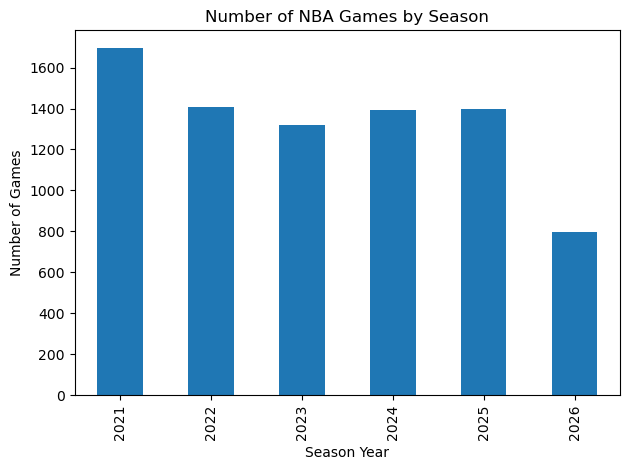

In [22]:
import matplotlib.pyplot as plt
season_counts = model_data["season_year"].value_counts().sort_index()

season_counts.plot(kind="bar")

plt.title("Number of NBA Games by Season")
plt.xlabel("Season Year")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

2026 is incomplete, so it will be treated as current/live prediction data.

Home win distribution.

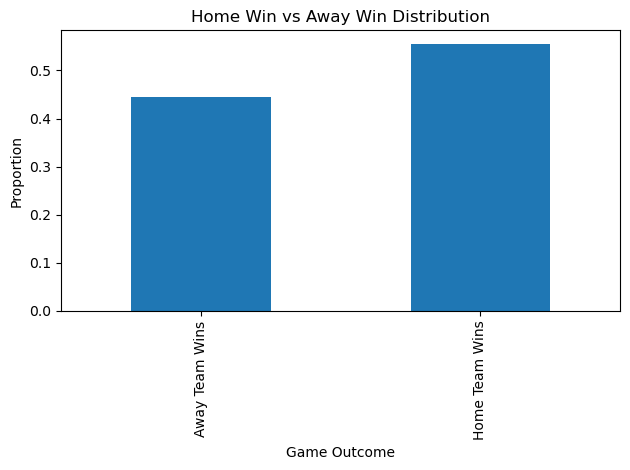

In [26]:
home_win_counts = (
    model_data["home_win"]
    .value_counts(normalize=True)
    .sort_index()
)

home_win_counts.index = [
    "Away Team Wins",   # 0
    "Home Team Wins"    # 1
]

home_win_counts.plot(kind="bar")

plt.title("Home Win vs Away Win Distribution")
plt.xlabel("Game Outcome")
plt.ylabel("Proportion")

plt.tight_layout()
plt.show()

Hometeam usually wins.

Regular season vs Playoffs distribution.

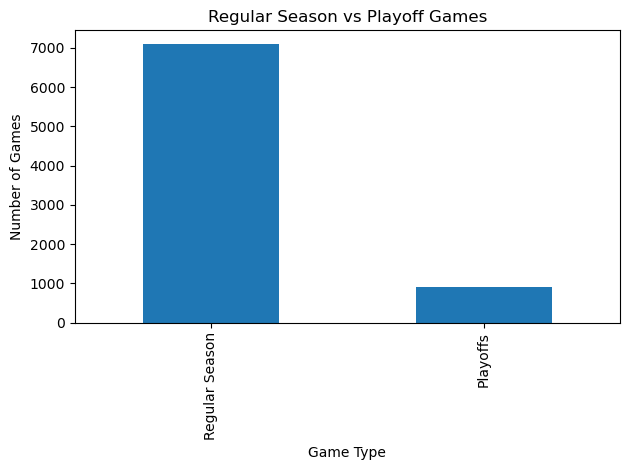

In [27]:
playoff_counts = model_data["is_playoff"].value_counts()

playoff_counts.index = ["Regular Season", "Playoffs"]

playoff_counts.plot(kind="bar")

plt.title("Regular Season vs Playoff Games")
plt.xlabel("Game Type")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

playoff games are fewer and behaves differently.

Home win throughout different seasons

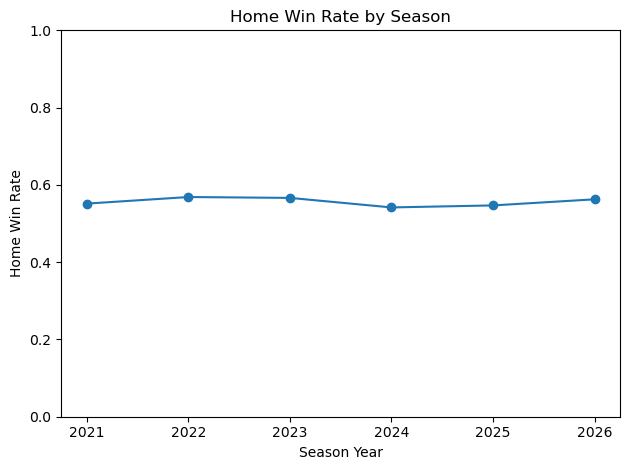

In [28]:
home_win_by_season = model_data.groupby("season_year")["home_win"].mean()

home_win_by_season.plot(kind="line", marker="o")

plt.title("Home Win Rate by Season")
plt.xlabel("Season Year")
plt.ylabel("Home Win Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

the team having home court advantage winning is above 0.55% almost every year.